# Modelagem e simulação

Roberto M. Cesar Jr. - IME - USP

rmcesar@usp.br

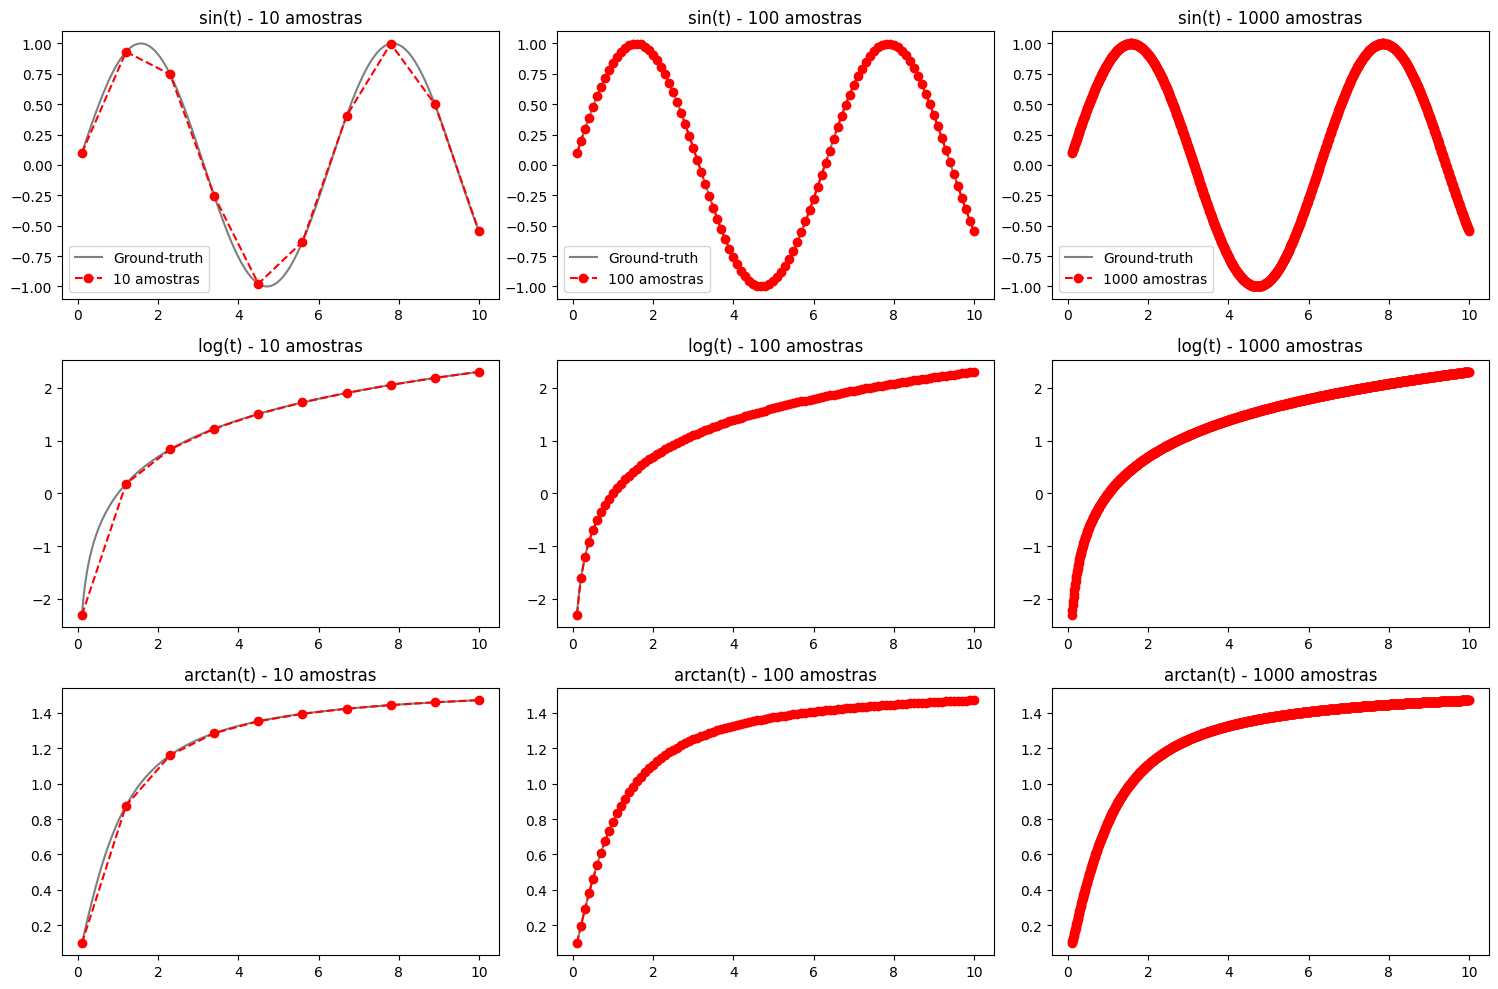

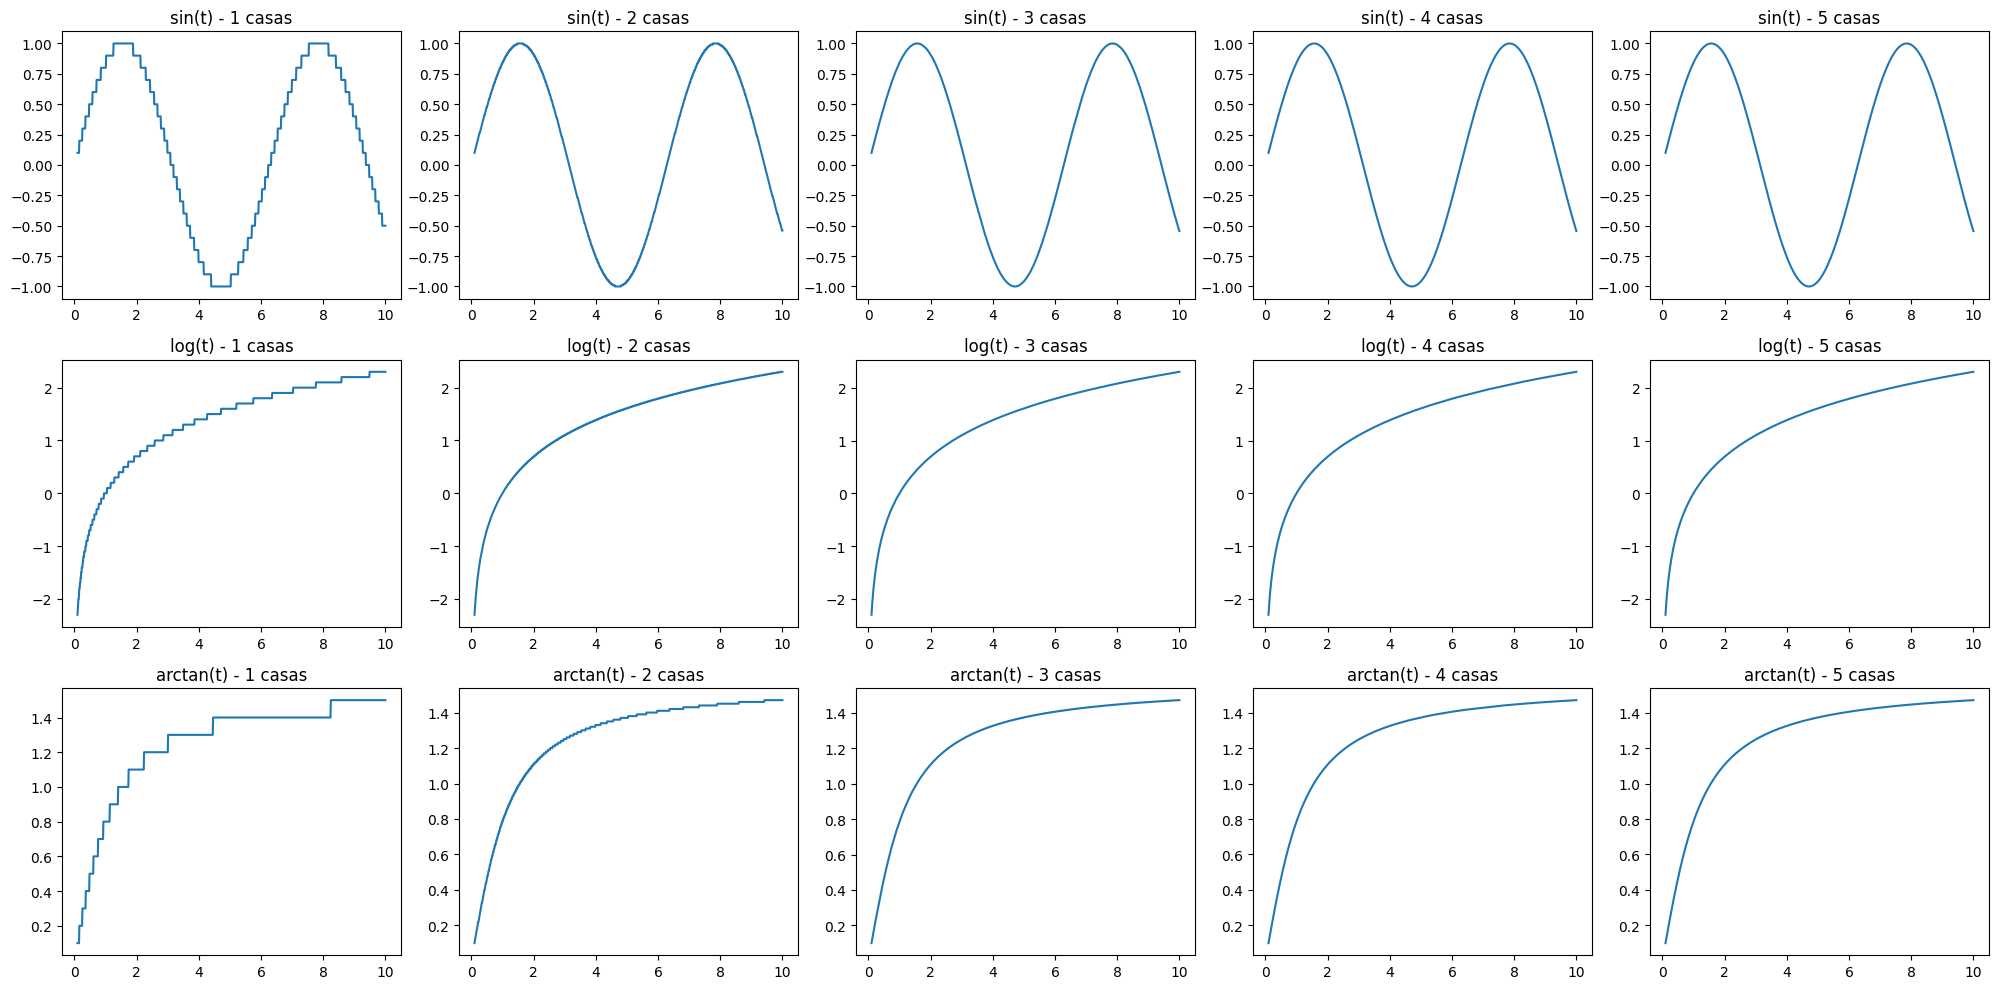

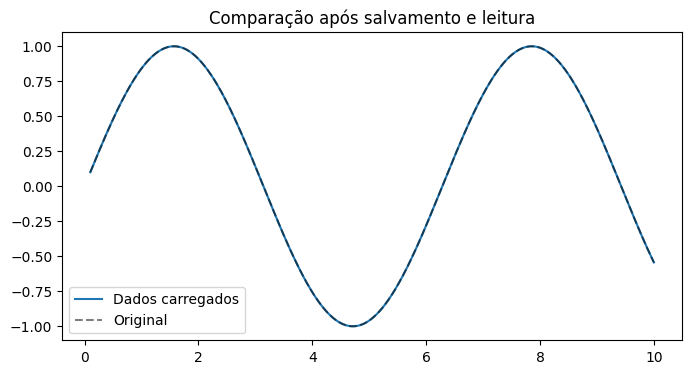

In [4]:
# Exercício 1 do capítulo 1 do livro de MAC0209.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Definir a função para gerar sinais
def generate_signals(t):
    return np.sin(t), np.log(t), np.arctan(t)

# Configuração do tempo (ground-truth com alta resolução)
t_high_res = np.linspace(0.1, 10, 10000)  # Evitando log(0)
sin_gt, log_gt, atan_gt = generate_signals(t_high_res)

# Função para amostrar os sinais
def sample_signals(num_samples):
    t = np.linspace(0.1, 10, num_samples)
    return t, generate_signals(t)

# Função para quantizar os sinais
def quantize_signal(signal, decimals):
    return np.round(signal, decimals)

# Testando diferentes taxas de amostragem
sample_rates = [10, 100, 1000]
fig, axes = plt.subplots(3, len(sample_rates), figsize=(15, 10))

for i, rate in enumerate(sample_rates):
    t, (sin_s, log_s, atan_s) = sample_signals(rate)

    axes[0, i].plot(t_high_res, sin_gt, 'k-', alpha=0.5, label="Ground-truth")
    axes[0, i].plot(t, sin_s, 'r--o', label=f"{rate} amostras")
    axes[0, i].set_title(f"sin(t) - {rate} amostras")
    axes[0, i].legend()

    axes[1, i].plot(t_high_res, log_gt, 'k-', alpha=0.5)
    axes[1, i].plot(t, log_s, 'r--o', label=f"{rate} amostras")
    axes[1, i].set_title(f"log(t) - {rate} amostras")

    axes[2, i].plot(t_high_res, atan_gt, 'k-', alpha=0.5)
    axes[2, i].plot(t, atan_s, 'r--o', label=f"{rate} amostras")
    axes[2, i].set_title(f"arctan(t) - {rate} amostras")

plt.tight_layout()
plt.show()

# Quantização: variando o número de casas decimais
decimals = range(1, 6)
fig, axes = plt.subplots(3, len(decimals), figsize=(20, 10))

t, (sin_s, log_s, atan_s) = sample_signals(1000)  # Taxa intermediária

for i, d in enumerate(decimals):
    sin_q = quantize_signal(sin_s, d)
    log_q = quantize_signal(log_s, d)
    atan_q = quantize_signal(atan_s, d)

    # Erro absoluto
    sin_error = np.abs(sin_q - sin_s)
    log_error = np.abs(log_q - log_s)
    atan_error = np.abs(atan_q - atan_s)

    axes[0, i].plot(t, sin_q, label=f"{d} casas")
    axes[0, i].set_title(f"sin(t) - {d} casas")

    axes[1, i].plot(t, log_q)
    axes[1, i].set_title(f"log(t) - {d} casas")

    axes[2, i].plot(t, atan_q)
    axes[2, i].set_title(f"arctan(t) - {d} casas")

plt.tight_layout()
plt.show()

# Salvando os dados em CSV
sin_df = pd.DataFrame({'t': t, 'sin(t)': sin_s})
log_df = pd.DataFrame({'t': t, 'log(t)': log_s})
atan_df = pd.DataFrame({'t': t, 'arctan(t)': atan_s})

sin_df.to_csv("sin_data.csv", index=False)
log_df.to_csv("log_data.csv", index=False)
atan_df.to_csv("atan_data.csv", index=False)

# Lendo e visualizando os dados
sin_loaded = pd.read_csv("sin_data.csv")
plt.figure(figsize=(8, 4))
plt.plot(sin_loaded['t'], sin_loaded['sin(t)'], label="Dados carregados")
plt.plot(t, sin_s, 'k--', label="Original", alpha=0.5)
plt.legend()
plt.title("Comparação após salvamento e leitura")
plt.show()
